In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/stock_prices/AAPL.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,company
0,2021-08-19 00:00:00-04:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple
1,2021-08-20 00:00:00-04:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple
2,2021-08-23 00:00:00-04:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple
3,2021-08-24 00:00:00-04:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple
4,2021-08-25 00:00:00-04:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple


In [3]:
df.shape

(1255, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1255 non-null   str    
 1   Open          1255 non-null   float64
 2   High          1255 non-null   float64
 3   Low           1255 non-null   float64
 4   Close         1255 non-null   float64
 5   Volume        1255 non-null   int64  
 6   Dividends     1255 non-null   float64
 7   Stock Splits  1255 non-null   float64
 8   ticker        1255 non-null   str    
 9   company       1255 non-null   str    
dtypes: float64(6), int64(1), str(3)
memory usage: 98.2 KB


In [5]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
ticker          0
company         0
dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)

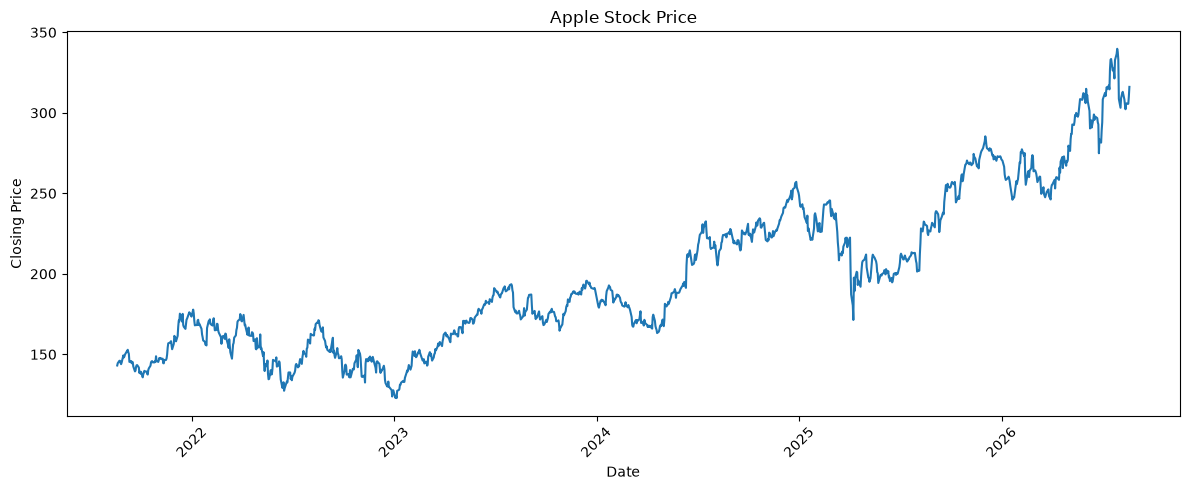

In [9]:
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"], utc=True)

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [10]:
df["daily_return"] = df["Close"].pct_change()

In [11]:
df[["Date", "Close", "daily_return"]].head()

,Date,Close,daily_return
0,2021-08-19 04:00:00+00:00,143.086960,NaN
1,2021-08-20 04:00:00+00:00,144.540222,0.010156
2,2021-08-23 04:00:00+00:00,146.022797,0.010257
3,2021-08-24 04:00:00+00:00,145.935013,-0.000601
4,2021-08-25 04:00:00+00:00,144.706070,-0.008421


In [12]:
df["daily_return"].describe()

count    1254.000000
mean        0.000788
std         0.017664
min        -0.092456
25%        -0.007917
50%         0.001137
75%         0.009547
max         0.153288
Name: daily_return, dtype: float64

In [13]:
df["volatility_30d"] = (
    df["daily_return"]
    .rolling(window=30)
    .std()
)

In [14]:
df[["Date", "volatility_30d"]].tail()

,Date,volatility_30d
1250,2026-08-13 04:00:00+00:00,0.021772
1251,2026-08-14 04:00:00+00:00,0.019890
1252,2026-08-17 04:00:00+00:00,0.019735
1253,2026-08-18 04:00:00+00:00,0.019891
1254,2026-08-19 04:00:00+00:00,0.020151
